# Carril 2.5 (post-experimento) sobre meta-labeling contextual: resumen narrativo y evidencia visual

Aplicación del motor de riesgo (EVT/CVaR *two-arm* + *position sizing*) sobre la señal **ya meta-filtrada** del experimento meta-labeling contextual greedy (sello `20260513T182131Z`, panel nominal **30** ramas). El primario del meta-labeling no se reentrena: se rehidrata `ModelFitStudyResult` desde disco y se colapsa `pred_label_side` a neutro en las filas que el meta-modelo veta (`meta_execute_pred=0`). Sobre esa vista se ejecutan dos brazos comparables (`sin_filtro` = meta solo, `con_filtro` = meta + EVT/CVaR) y las tres políticas de *sizing* congeladas (`identity`, `fixed_control`, `vol_target`).

**Métrica primaria:** Sharpe agregado *out-of-sample* del brazo control (`meta_sharpe`) y filtrado (`filt_sharpe`) y su delta. **MaxDD primario:** mediana del MaxDD entre *outer folds* (`meta_max_drawdown_fold_median`, `filt_max_drawdown_fold_median`).

El gate `execution_risk_two_arm_acceptance` se mantiene como **lectura diagnóstica** en la sección 2 (conteo de sub-gates, incluido `gate_dsr_passed` sobre el DSR local del paso 2.5). El **cierre del carril** en la sección 8 usa solo el DSR recalculado desde retornos OOS con `N_total = n_trials_meta_shortlist + n_trials_meta_greedy + n_trials_25` por celda `(symbol, method)`.

**Insumos:** `post_experiment_metalabeling_risk_lane_report.json` por rama bajo `reports/validation/experiments/*/execution_risk/post_experiment_metalabeling/frozen_20260520T0238Z/`, aguas arriba del greedy meta-labeling (`07_resumen_greedy_contextual_meta_labeling.ipynb`, sello `20260513T182131Z`).

**Productos:** tablas CSV y figuras PNG bajo `reports/figures/exp_synthesis/post_experiment_metalabeling/` (listado completo en la sección 9).

Diferencia clave con el carril 2.5 del Exp 2 (`06_resumen_carril_riesgo_greedy_contextual.ipynb`): la señal de partida ya está filtrada por el meta-modelo, por lo que el EVT opera sobre una distribución mucho más selectiva. El interés principal es responder dos preguntas: (i) cuánto aporta EVT por encima del meta solo en términos de Sharpe agregado y MaxDD por fold; (ii) cuántas ramas pasan el gate diagnóstico `execution_risk_two_arm_acceptance`.


In [37]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.options.display.max_columns = 60
pd.options.display.max_rows = 200
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'


COLUMNAS_ES = {
    'cell_label': 'celda',
    'symbol': 'simbolo',
    'method': 'metodo',
    'family': 'familia',
    'winner_subset': 'subset_ganador',
    'is_accepted': 'aceptado',
    'gate_defensive_passed': 'defensivo_pasa',
    'gate_dsr_passed': 'dsr_pasa',
    'gate_same_folds_passed': 'mismos_folds_pasa',
    'meta_coverage': 'cobertura_meta',
    'filt_coverage': 'cobertura_filtrado',
    'meta_sharpe': 'sharpe_meta',
    'filt_sharpe': 'sharpe_filtrado',
    'delta_sharpe': 'delta_sharpe',
    'meta_dsr': 'dsr_meta_diagnostico',
    'filt_dsr': 'dsr_filtrado_diagnostico',
    'delta_dsr': 'delta_dsr_diagnostico',
    'meta_max_drawdown': 'maxdd_meta_agregado',
    'filt_max_drawdown': 'maxdd_filtrado_agregado',
    'meta_max_drawdown_fold_median': 'maxdd_meta_mediana_fold',
    'filt_max_drawdown_fold_median': 'maxdd_filtrado_mediana_fold',
    'delta_max_drawdown': 'delta_maxdd_agregado',
    'meta_realized_cvar': 'cvar_realizado_meta',
    'filt_realized_cvar': 'cvar_realizado_filtrado',
    'delta_realized_cvar': 'delta_cvar_realizado',
    'delta_coverage': 'delta_cobertura',
    'has_evt_effect': 'evt_modifica_senial',
    'identity_sharpe': 'sharpe_identity',
    'fixed_control_sharpe': 'sharpe_fixed_control',
    'vol_target_sharpe': 'sharpe_vol_target',
    'identity_dsr': 'dsr_identity_diagnostico',
    'fixed_control_dsr': 'dsr_fixed_control_diagnostico',
    'vol_target_dsr': 'dsr_vol_target_diagnostico',
}


def _nombre_columna_es(nombre: str) -> str:
    return COLUMNAS_ES.get(nombre, nombre)


def a_es(frame: pd.DataFrame | pd.Series) -> pd.DataFrame:
    if isinstance(frame, pd.Series):
        frame = frame.to_frame(name=frame.name)
    vista = frame.copy()
    vista.columns = [_nombre_columna_es(str(col)) for col in vista.columns]
    if vista.index.name:
        vista.index.name = _nombre_columna_es(str(vista.index.name))
    if isinstance(vista.index, pd.MultiIndex):
        vista.index = vista.index.set_names([
            _nombre_columna_es(str(name)) if name is not None else name
            for name in vista.index.names
        ])
    return vista


def display_es(frame: pd.DataFrame | pd.Series) -> None:
    display(a_es(frame))


def locate_repo_root(start: Path | None = None) -> Path:
    root = (start or Path.cwd()).resolve()
    while root != root.parent and not (root / 'src').exists():
        root = root.parent
    if not (root / 'src').exists():
        raise FileNotFoundError('No se encontró la raíz del repo (carpeta src/).')
    return root


ROOT = locate_repo_root()
EVIDENCE_DIR = ROOT / 'evidence_utils'
if str(EVIDENCE_DIR) not in sys.path:
    sys.path.insert(0, str(EVIDENCE_DIR))

from phase_summaries import (
    POST_EXPERIMENT_METALABELING_STAMP_DEFAULT,
    POST_EXPERIMENT_METALABELING_SUBDIR_DEFAULT,
    load_dsr_exact_post_experiment_table,
    load_post_experiment_metalabeling_summary,
)

REPORT_ROOT = ROOT / 'reports' / 'validation' / 'experiments'
FIG_DIR = ROOT / 'reports' / 'figures' / 'exp_synthesis' / 'post_experiment_metalabeling'
FIG_DIR.mkdir(parents=True, exist_ok=True)


## 1. Carga y vista preliminar de las ramas meta-frozen

Cada fila es una rama meta-frozen. La vista preliminar muestra **Sharpe agregado** del brazo control y filtrado, su delta y la **mediana del MaxDD entre folds** para ambos brazos. La aceptación binaria del gate aparece como columna informativa.

Cada fila representa una rama ganadora del greedy contextual `20260513T182131Z` sobre la que se aplicó el carril 2.5 (`frozen_20260520T0238Z`). El brazo `meta_*` es la señal ya filtrada por el meta-modelo (sin EVT); el brazo `filt_*` aplica EVT/CVaR encima.

In [38]:
post = load_post_experiment_metalabeling_summary(REPORT_ROOT)
post.to_csv(FIG_DIR / 'post_experiment_metalabeling_raw.csv', index=False)
print(f'N de ramas leídas: {len(post)}')
preview_cols = [
    'symbol', 'method', 'family', 'winner_subset', 'is_accepted',
    'meta_coverage', 'filt_coverage',
    'meta_sharpe', 'filt_sharpe', 'delta_sharpe',
    'meta_max_drawdown_fold_median', 'filt_max_drawdown_fold_median',
]
display_es(post[preview_cols].round(4))


N de ramas leídas: 30


,simbolo,metodo,familia,subset_ganador,aceptado,cobertura_meta,cobertura_filtrado,sharpe_meta,sharpe_filtrado,delta_sharpe,maxdd_meta_mediana_fold,maxdd_filtrado_mediana_fold
0,BNBUSDT,fixed_horizon,lstm,core_only,False,0.5249,0.5249,-0.0181,-0.0181,0.0000,-0.4596,-0.4596
1,BNBUSDT,fixed_horizon,xgboost,core_only,False,0.5438,0.5438,0.0107,0.0107,0.0000,-0.3737,-0.3737
2,BNBUSDT,trend_scanning,lstm,core_only,True,0.6053,0.5941,0.0212,0.0210,-0.0003,-0.7695,-0.7638
3,BNBUSDT,trend_scanning,xgboost,core_only,False,0.6189,0.6189,0.0096,0.0096,0.0000,-0.7615,-0.7615
4,BNBUSDT,triple_barrier,lstm,core_only,False,0.4682,0.4682,0.0061,0.0061,0.0000,-0.1767,-0.1767
5,BNBUSDT,triple_barrier,xgboost,core_only,False,0.6211,0.6211,-0.0151,-0.0151,0.0000,-0.2726,-0.2726
6,BTCUSDT,fixed_horizon,lstm,core_only,False,0.3859,0.3859,-0.0159,-0.0159,0.0000,-0.2718,-0.2718
7,BTCUSDT,fixed_horizon,xgboost,core_only,False,0.4939,0.4939,-0.0063,-0.0063,0.0000,-0.3398,-0.3398
8,BTCUSDT,trend_scanning,lstm,core_only,True,0.5373,0.5346,0.0248,0.0229,-0.0019,-0.6819,-0.6819
9,BTCUSDT,trend_scanning,xgboost,core_only,False,0.6017,0.5917,0.0095,0.0071,-0.0024,-0.6790,-0.6790


## 2. Resultado del *gate* `execution_risk_two_arm_acceptance` (lectura diagnóstica)

Conteo global del veredicto `is_accepted` y descomposición por sub-gate (defensivo: mejora MaxDD o CVaR realizado; DSR significativo: `>= 0.95`). Mismo umbral que el carril 2.5 del Exp 2 para comparabilidad estructural directa.

Esta sección **no es la lectura primaria** del paso (esa lectura se hace sobre Sharpe agregado y MaxDD por fold a partir de 3); aquí se reporta el desglose del gate como diagnóstico contractual. La deflación coherente del carril completo de meta-labeling se reporta como **diagnóstico embebido** en la sección 8 con el N total acumulado.


Aceptación del gate por componente


,pass_count,pass_ratio
is_accepted (global),3,0.1
gate_defensive_passed,30,1.0
gate_dsr_passed,3,0.1
gate_same_folds_passed,30,1.0


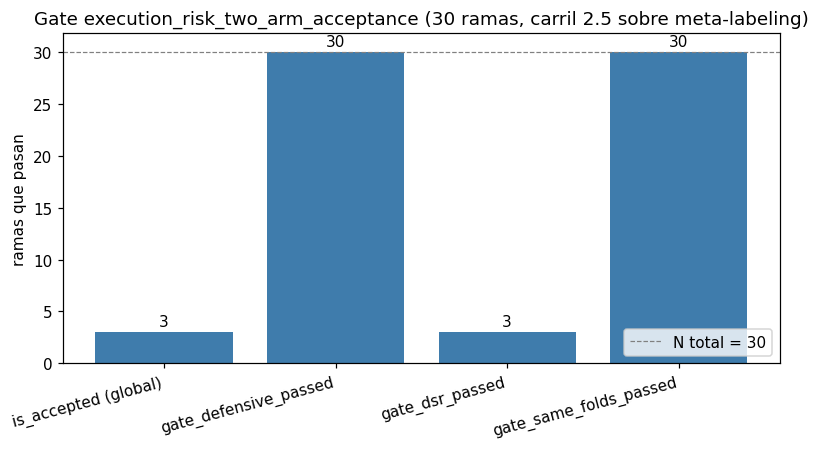

In [39]:
accept_counts = {
    'is_accepted (global)': int(post['is_accepted'].fillna(False).sum()),
    'gate_defensive_passed': int(post['gate_defensive_passed'].fillna(False).sum()),
    'gate_dsr_passed': int(post['gate_dsr_passed'].fillna(False).sum()),
    'gate_same_folds_passed': int(post['gate_same_folds_passed'].fillna(False).sum()),
}
accept_df = pd.DataFrame(
    {
        'pass_count': list(accept_counts.values()),
        'pass_ratio': [v / len(post) for v in accept_counts.values()],
    },
    index=list(accept_counts.keys()),
)
print('Aceptación del gate por componente')
display(accept_df.round(3))

n_total = len(post)
label_headroom = max(1.5, n_total * 0.06)

fig, ax = plt.subplots(figsize=(7.4, 4.2))
bars = ax.bar(accept_df.index, accept_df['pass_count'], color='#3F7CAC')
ax.set_ylabel('Ramas que pasan')
ax.set_ylim(0, n_total + label_headroom)
ax.axhline(n_total, color='gray', linestyle='--', linewidth=0.8, label=f'N total = {n_total}')
for bar, value in zip(bars, accept_df['pass_count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + label_headroom * 0.15,
        f'{int(value)}',
        ha='center',
        va='bottom',
    )
ax.set_title(f'Gate execution_risk_two_arm_acceptance ({n_total} ramas, carril 2.5 sobre meta-labeling)')
ax.legend(loc='lower right')
plt.xticks(rotation=15, ha='right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'gate_acceptance_counts.png')
plt.show()


## 3. Efecto marginal de EVT/CVaR sobre la señal meta

Diferencias `con_filtro - sin_filtro` (delta) sobre la rama. `delta_coverage` mide cuánto reduce EVT la cobertura ya recortada por el meta. Un valor cercano a 0 significa que el meta agotó el margen de filtrado y EVT no aporta veto adicional. La métrica primaria del efecto económico es **`delta_sharpe`** (Sharpe agregado del brazo filtrado menos el del control); `delta_realized_cvar` se mantiene como lectura defensiva complementaria. El `delta_max_drawdown` agregado aparece solo como diagnóstico auxiliar de la serie concatenada, no como métrica primaria del carril.

Conteo: ramas donde EVT modifica la señal meta


,n_ramas
evt_modifica_senial,
False,24
True,6



Top 10 ramas con mayor delta EVT (orden por suma absoluta de delta_coverage y delta_realized_cvar)


,celda,familia,delta_cobertura,delta_cvar_realizado,delta_maxdd_agregado,delta_sharpe,aceptado
2,BNBUSDT/trend_scanning/lstm,lstm,-0.011170,0.003623,0.0,-0.000267,True
14,ETHUSDT/trend_scanning/lstm,lstm,-0.011512,0.000000,0.0,-0.005640,False
9,BTCUSDT/trend_scanning/xgboost,xgboost,-0.010023,0.000004,-0.0,-0.002386,False
15,ETHUSDT/trend_scanning/xgboost,xgboost,-0.008362,0.000098,0.0,-0.002762,False
11,BTCUSDT/triple_barrier/xgboost,xgboost,-0.004696,0.000003,0.0,0.001099,False
8,BTCUSDT/trend_scanning/lstm,lstm,-0.002692,0.000000,-0.0,-0.001889,True
25,XRPUSDT/fixed_horizon/xgboost,xgboost,0.000000,0.000000,0.0,0.000000,False
24,XRPUSDT/fixed_horizon/lstm,lstm,0.000000,0.000000,0.0,0.000000,False
18,SOLUSDT/fixed_horizon/lstm,lstm,0.000000,0.000000,0.0,0.000000,False
26,XRPUSDT/trend_scanning/lstm,lstm,0.000000,0.000000,0.0,0.000000,True


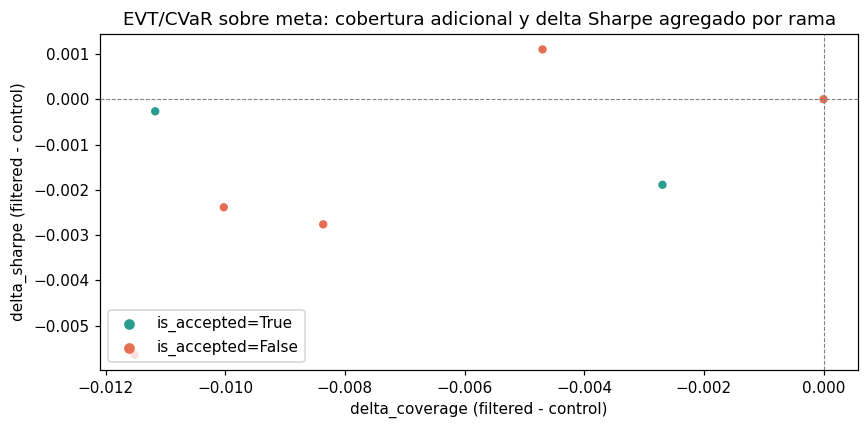

In [40]:
effect_df = post[[
    'cell_label', 'family',
    'delta_coverage', 'delta_realized_cvar', 'delta_max_drawdown',
    'delta_sharpe', 'is_accepted',
]].copy()
effect_df = effect_df.fillna({
    'delta_coverage': 0.0,
    'delta_realized_cvar': 0.0,
    'delta_max_drawdown': 0.0,
    'delta_sharpe': 0.0,
})
# El efecto operativo de EVT se define por cambios en cobertura o CVaR realizado.
effect_df['has_evt_effect'] = (
    (effect_df['delta_coverage'].abs() > 1e-9)
    | (effect_df['delta_realized_cvar'].abs() > 1e-9)
)
print('Conteo: ramas donde EVT modifica la señal meta')
display_es(effect_df.groupby('has_evt_effect').size().rename('n_ramas'))

effect_df['abs_delta'] = effect_df['delta_coverage'].abs() + effect_df['delta_realized_cvar'].abs()
effect_df = effect_df.sort_values('abs_delta', ascending=False)
print('\nTop 10 ramas con mayor delta EVT (orden por suma absoluta de delta_coverage y delta_realized_cvar)')
display_es(effect_df[[
    'cell_label', 'family',
    'delta_coverage', 'delta_realized_cvar', 'delta_max_drawdown',
    'delta_sharpe', 'is_accepted',
]].head(10).round(6))

post_plot = post.copy()
post_plot['delta_coverage'] = post_plot['delta_coverage'].fillna(0.0).astype(float)
post_plot['delta_sharpe'] = post_plot['delta_sharpe'].fillna(0.0).astype(float)
fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.scatter(
    post_plot['delta_coverage'],
    post_plot['delta_sharpe'],
    c=post_plot['is_accepted'].map({True: '#2A9D8F', False: '#E76F51'}),
    s=42,
    edgecolor='white',
)
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')
ax.set_xlabel('delta_coverage (filtered - control)')
ax.set_ylabel('delta_sharpe (filtered - control)')
ax.set_title('EVT/CVaR sobre meta: cobertura adicional y delta Sharpe agregado por rama')
for color, label in [('#2A9D8F', 'is_accepted=True'), ('#E76F51', 'is_accepted=False')]:
    ax.scatter([], [], c=color, label=label)
ax.legend(loc='lower left')
fig.tight_layout()
fig.savefig(FIG_DIR / 'delta_coverage_vs_delta_sharpe.png')
plt.show()


## 4. Cobertura y operativa de la señal meta-filtrada

`meta_coverage` describe la fracción de filas que el meta deja ejecutables (1 - tasa de filtrado). Sobre esa base, EVT puede o no añadir veto. La gráfica compara cobertura meta vs. cobertura tras EVT por rama; los puntos en la diagonal indican que EVT no recortó adicionalmente.

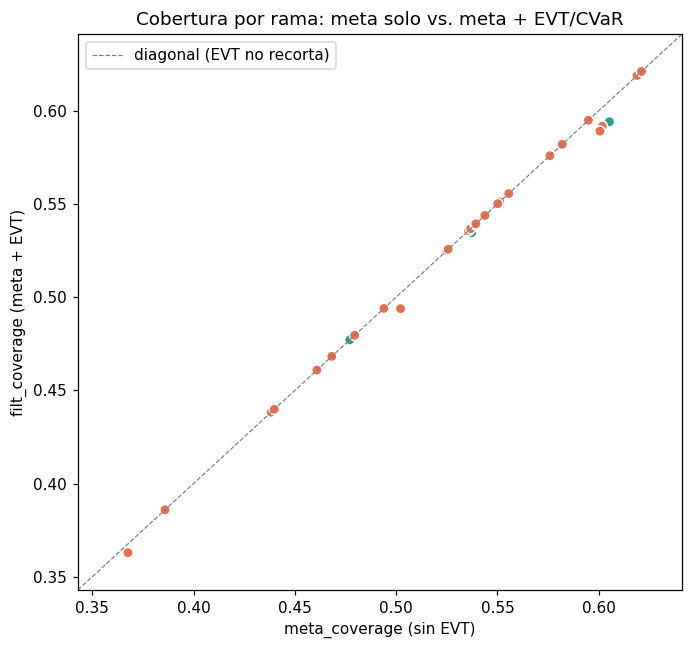

In [41]:
fig, ax = plt.subplots(figsize=(6.4, 6.0))
colors = post['is_accepted'].map({True: '#2A9D8F', False: '#E76F51'}).fillna('#999999')
ax.scatter(post['meta_coverage'], post['filt_coverage'], c=colors, s=46, edgecolor='white')
lims = [min(post['meta_coverage'].min(), post['filt_coverage'].min()) - 0.02,
        max(post['meta_coverage'].max(), post['filt_coverage'].max()) + 0.02]
ax.plot(lims, lims, color='gray', linewidth=0.8, linestyle='--', label='diagonal (EVT no recorta)')
ax.set_xlabel('meta_coverage (sin EVT)')
ax.set_ylabel('filt_coverage (meta + EVT)')
ax.set_title('Cobertura por rama: meta solo vs. meta + EVT/CVaR')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(FIG_DIR / 'meta_vs_filtered_coverage.png')
plt.show()


## 5. Mapa de aceptación por símbolo × método de etiquetado

*Heatmap* (`symbol` × `method`) con el número de familias (`xgboost`, `lstm`) que pasan el gate diagnóstico. Permite localizar visualmente qué celdas tienen evidencia contractual post-meta. La interpretación operativa primaria sigue siendo el delta de **Sharpe agregado** y el **MaxDD por fold** (3 y 7).


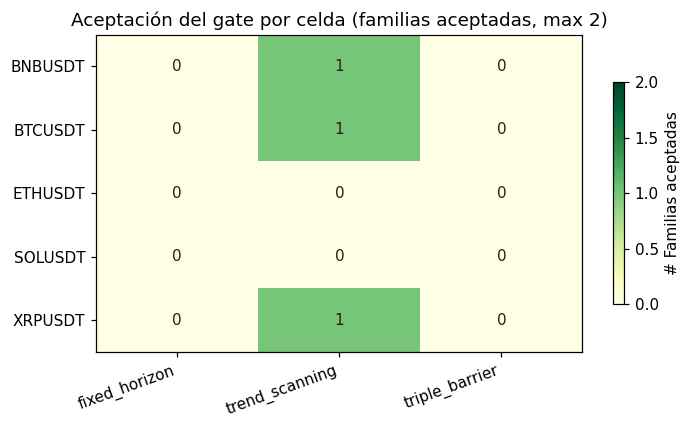

method,fixed_horizon,trend_scanning,triple_barrier
symbol,,,
BNBUSDT,0,1,0
BTCUSDT,0,1,0
ETHUSDT,0,0,0
SOLUSDT,0,0,0
XRPUSDT,0,1,0


In [42]:
post['accepted_int'] = post['is_accepted'].map({True: 1.0, False: 0.0}).fillna(0.0)
heat = post.pivot_table(index='symbol', columns='method', values='accepted_int', aggfunc='sum').fillna(0.0)

fig, ax = plt.subplots(figsize=(6.6, 4.0))
im = ax.imshow(heat.values, cmap='YlGn', aspect='auto', vmin=0, vmax=2)
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=20, ha='right')
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{int(heat.values[i, j])}", ha='center', va='center', color='#222')
ax.set_title('Aceptación del gate por celda (familias aceptadas, max 2)')
fig.colorbar(im, ax=ax, shrink=0.7, label='# Familias aceptadas')
fig.tight_layout()
fig.savefig(FIG_DIR / 'acceptance_heatmap.png')
plt.show()
display(heat.astype(int))


## 6. Comparativa de políticas de *sizing* (`identity`, `fixed_control`, `vol_target`)

Sobre el brazo filtrado, las tres políticas de *sizing* se evalúan con la misma señal; comparamos el **Sharpe agregado** para ver si alguna política cambia materialmente el resultado respecto del baseline `identity`. En la ejecución actual `fixed_control` coincide con `identity` en todas las ramas, mientras que `vol_target` introduce la única variación relevante.

Sharpe agregado por política de sizing (30 ramas)


,mean,median,std,min,max
policy,,,,,
fixed_control_sharpe,-0.0071,-0.0091,0.0245,-0.0753,0.0357
identity_sharpe,-0.0071,-0.0091,0.0245,-0.0753,0.0357
vol_target_sharpe,-0.0068,-0.0051,0.0251,-0.0657,0.0548


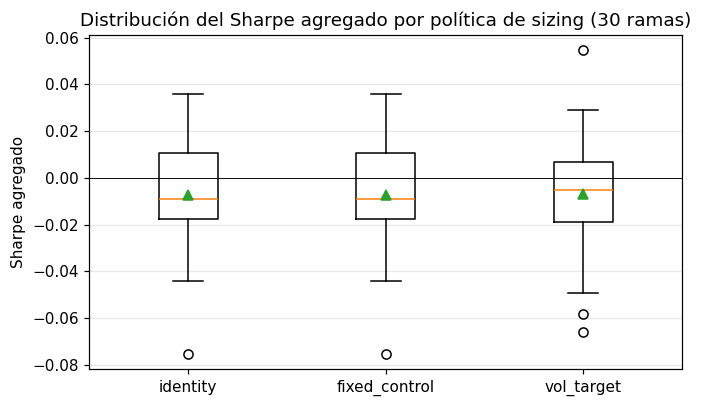

In [43]:
sizing_df = post[[
    'cell_label', 'family',
    'identity_sharpe', 'fixed_control_sharpe', 'vol_target_sharpe',
]].copy()
sizing_long = sizing_df.melt(
    id_vars=['cell_label', 'family'],
    var_name='policy',
    value_name='sharpe',
).dropna(subset=['sharpe'])
sizing_summary = (
    sizing_long.groupby('policy')['sharpe']
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .round(4)
)
print(f'Sharpe agregado por política de sizing ({len(post)} ramas)')
display(sizing_summary)

a_es(sizing_df).to_csv(FIG_DIR / 'sizing_sharpe_comparison.csv', index=False)

fig, ax = plt.subplots(figsize=(6.4, 3.8))
policies = ['identity_sharpe', 'fixed_control_sharpe', 'vol_target_sharpe']
labels = ['identity', 'fixed_control', 'vol_target']
data = [post[p].dropna().to_numpy() for p in policies]
ax.boxplot(data, tick_labels=labels, showmeans=True)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_ylabel('Sharpe agregado')
ax.set_title(f'Distribución del Sharpe agregado por política de sizing ({len(post)} ramas)')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'sizing_sharpe_box.png')
plt.show()


## 7. Efecto del filtro EVT/CVaR sobre el MaxDD primario (mediana entre folds)

La métrica de *drawdown* defendible en este carril es la **mediana del MaxDD entre *outer folds*** (`meta_max_drawdown_fold_median` / `filt_max_drawdown_fold_median`), no el MaxDD sobre la serie concatenada de folds (artefacto metodológico; las columnas agregadas permanecen solo en la tabla de la sección 1).

Comparativa **brazo filtrado vs. control meta** por rama, en paralelo a la sección 3 para Sharpe: un delta positivo (`filt - meta`) indica un drawdown típico por fold menos profundo tras el filtro EVT/CVaR.


Estadísticos del delta MaxDD fold (filtrado - meta; positivo = drawdown menos profundo)


,valor
n_ramas,30.000000
n_mejoradas,3.000000
n_empeoradas,0.000000
n_neutrales,27.000000
media_delta,0.000291
mediana_delta,0.000000
minimo_delta,0.000000
maximo_delta,0.005674


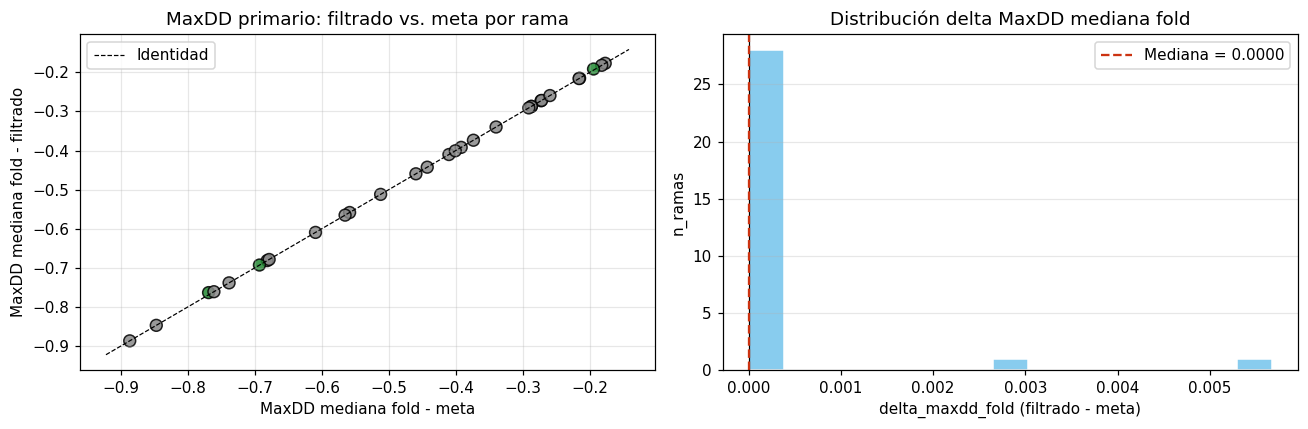

In [44]:
post_maxdd = post.dropna(
    subset=['meta_max_drawdown_fold_median', 'filt_max_drawdown_fold_median']
).copy()
for col in ('meta_max_drawdown_fold_median', 'filt_max_drawdown_fold_median'):
    post_maxdd[col] = pd.to_numeric(post_maxdd[col], errors='coerce')

post_maxdd['delta_maxdd_fold'] = (
    post_maxdd['filt_max_drawdown_fold_median'] - post_maxdd['meta_max_drawdown_fold_median']
)

delta_maxdd_stats = {
    'n_ramas': int(len(post_maxdd)),
    'n_mejoradas': int((post_maxdd['delta_maxdd_fold'] > 0).sum()),
    'n_empeoradas': int((post_maxdd['delta_maxdd_fold'] < 0).sum()),
    'n_neutrales': int((post_maxdd['delta_maxdd_fold'] == 0).sum()),
    'media_delta': float(post_maxdd['delta_maxdd_fold'].mean()),
    'mediana_delta': float(post_maxdd['delta_maxdd_fold'].median()),
    'minimo_delta': float(post_maxdd['delta_maxdd_fold'].min()),
    'maximo_delta': float(post_maxdd['delta_maxdd_fold'].max()),
}
pd.DataFrame([delta_maxdd_stats]).to_csv(
    FIG_DIR / 'post_experiment_metalabeling_delta_maxdd_fold_stats.csv', index=False
)

export_cols = [
    'symbol', 'method', 'family',
    'meta_max_drawdown_fold_median', 'filt_max_drawdown_fold_median', 'delta_maxdd_fold',
]
a_es(post_maxdd[export_cols]).to_csv(
    FIG_DIR / 'post_experiment_metalabeling_maxdd_fold_comparison.csv', index=False
)

print('Estadísticos del delta MaxDD fold (filtrado - meta; positivo = drawdown menos profundo)')
display(pd.DataFrame([delta_maxdd_stats]).T.rename(columns={0: 'valor'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.scatter(
    post_maxdd['meta_max_drawdown_fold_median'],
    post_maxdd['filt_max_drawdown_fold_median'],
    c=['#228833' if v > 0 else '#CC3311' if v < 0 else '#888888'
       for v in post_maxdd['delta_maxdd_fold']],
    edgecolor='black', s=60, alpha=0.85,
)
lo = float(post_maxdd[['meta_max_drawdown_fold_median', 'filt_max_drawdown_fold_median']].min().min())
hi = float(post_maxdd[['meta_max_drawdown_fold_median', 'filt_max_drawdown_fold_median']].max().max())
pad = max((hi - lo) * 0.05, 0.005)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
        color='black', linestyle='--', linewidth=0.8, label='Identidad')
ax.set_xlabel('MaxDD mediana fold - meta')
ax.set_ylabel('MaxDD mediana fold - filtrado')
ax.set_title('MaxDD primario: filtrado vs. meta por rama')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(post_maxdd['delta_maxdd_fold'].values, bins=15,
        color='#88CCEE', edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(
    post_maxdd['delta_maxdd_fold'].median(), color='#CC3311', linestyle='--',
    label=f'Mediana = {post_maxdd["delta_maxdd_fold"].median():.4f}',
)
ax.set_xlabel('delta_maxdd_fold (filtrado - meta)')
ax.set_ylabel('n_ramas')
ax.set_title('Distribución delta MaxDD mediana fold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'post_experiment_metalabeling_delta_maxdd_fold.png')
plt.show()


## 8. DSR deflactado del carril meta-labeling (N total por celda)

Métrica de **multiplicidad de hipótesis** al cierre del carril meta-labeling: *Deflated Sharpe Ratio* para los dos brazos del paso 2.5 meta (`control` = meta solo, `filtered` = meta + EVT/CVaR), calculado **desde los retornos OOS reales** (concatenación cronológica de `executed_position * return_realized` por fold). Fuente: `scripts/recompute_dsr_post_experiment_total.py --track metalabeling` -> `reports/validation/dsr_exact/dsr_exact_post_experiment_metalabeling.csv`.

**Lectura:** solo cuenta el **DSR recalculado** (retornos OOS + `N_total` coherente + `sr_std` empírico) frente al umbral 0.95. El DSR que la pipeline escribe en el JSON del paso 2.5 **no se usa aquí**: hereda N y a menudo `sr_std=0`, así que no es comparable como cierre del carril.

**N de deflación (simétrico al carril supervisado):** se acumula por celda `(symbol, method)` como

`N_total = n_trials_meta_shortlist + n_trials_meta_greedy + n_trials_25`,

donde:

- `n_trials_meta_shortlist`: trials del shortlist meta (`n_trials_in_ledger` del JSON más reciente por celda).
- `n_trials_meta_greedy`: nodos evaluados en la fase greedy meta (familias que compiten en la misma celda).
- `n_trials_25 = 2 * n_estudios_25_meta_en_la_celda`: brazos `control` + `filtered` del propio paso 2.5 meta.

El `sr_std` se estima como desviación típica (ddof=1) del pool de Sharpes intra-celda del shortlist meta y del greedy meta. El CSV persiste `n_total_source` y `n_inherited_legacy` para trazabilidad.

**Salida en pantalla:** tabla resumen por brazo (`control` / `filtered`); top 5 del brazo filtrado; scatter control vs. filtrado. El detalle fila a fila con descomposición de N queda en `post_experiment_metalabeling_dsr_table.csv`.

**Gráfico:** scatter DSR control vs. filtrado. La economía primaria del paso sigue en Sharpe y MaxDD por fold (secciones 3 y 7).


DSR carril meta (umbral 0.95, N total por celda)


,brazo,n_ramas,n_dsr_ge_095,mediana_dsr,maximo_dsr,minimo_dsr,mediana_n_trials_total
0,control,30,1,0.0006,0.9856,0.0,19.0
1,filtered,30,1,0.0007,0.9856,0.0,19.0



Top 5 ramas meta por DSR (brazo filtrado)


,metodo,metodo_meta,familia,rama,sharpe_observado,n_trials_total,dsr,dsr_supera_0_95
0,trend_scanning,lstm,lstm,core_only-fc869212f645,0.0357,18,0.9856,True
1,trend_scanning,lstm,lstm,core_only-812ee737bb20,0.0210,18,0.7532,False
2,triple_barrier,xgboost,xgboost,core_only-89ed5429c23a,0.0212,21,0.6721,False
3,triple_barrier,lstm,lstm,core_only-8241f81f08f2,0.0153,21,0.5434,False
4,triple_barrier,lstm,lstm,attention-derivatives_futures-microstructure-o...,0.0223,22,0.4337,False


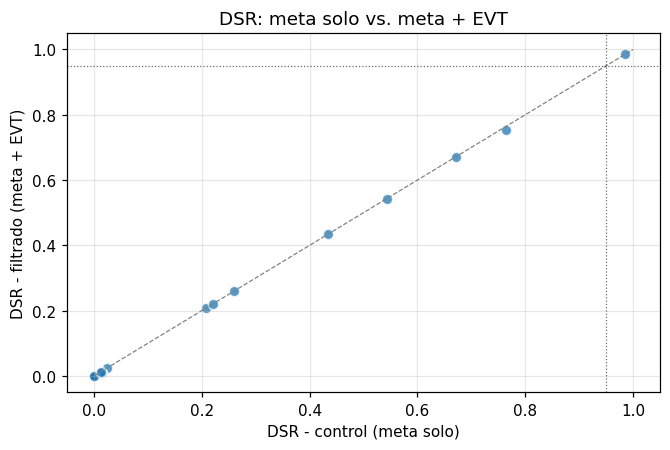

In [45]:
VALIDATION_ROOT = ROOT / 'reports' / 'validation'
dsr_exact = load_dsr_exact_post_experiment_table(VALIDATION_ROOT, track='metalabeling')
DSR_UMBRAL = 0.95

if dsr_exact.empty:
    print(
        'No se encontró reports/validation/dsr_exact/dsr_exact_post_experiment_metalabeling.csv. '
        'Ejecuta primero scripts/recompute_dsr_post_experiment_total.py --track metalabeling.'
    )
else:
    cols_full = [
        'method', 'method_subdir', 'family', 'branch_id', 'arm',
        'observed_sr', 'n_obs',
        'n_trials_meta_shortlist', 'n_trials_meta_greedy', 'n_trials_25',
        'n_trials_total', 'sr_std_total', 'expected_max_sr_total',
        'psr_exact', 'dsr_exact', 'is_significant_dsr',
    ]
    cols_full = [c for c in cols_full if c in dsr_exact.columns]

    cols_preview = [
        'method', 'method_subdir', 'family', 'branch_id',
        'observed_sr', 'n_trials_total', 'dsr_exact', 'is_significant_dsr',
    ]
    cols_preview = [c for c in cols_preview if c in dsr_exact.columns]

    columnas_dsr_es = {
        'method': 'metodo',
        'method_subdir': 'metodo_meta',
        'family': 'familia',
        'branch_id': 'rama',
        'arm': 'brazo',
        'observed_sr': 'sharpe_observado',
        'n_obs': 'n_obs',
        'n_trials_meta_shortlist': 'n_trials_meta_shortlist',
        'n_trials_meta_greedy': 'n_trials_meta_greedy',
        'n_trials_25': 'n_trials_25',
        'n_trials_total': 'n_trials_total',
        'sr_std_total': 'sr_std_intra_celda',
        'expected_max_sr_total': 'sharpe_max_esperado',
        'psr_exact': 'psr',
        'dsr_exact': 'dsr',
        'is_significant_dsr': 'dsr_supera_0_95',
    }

    dsr_sorted = dsr_exact.sort_values(
        ['dsr_exact'], ascending=False, na_position='last'
    ).reset_index(drop=True)
    vista_full = dsr_sorted[cols_full].rename(columns=columnas_dsr_es)
    vista_full.to_csv(FIG_DIR / 'post_experiment_metalabeling_dsr_table.csv', index=False)

    summary_rows = []
    for arm_label in ('control', 'filtered'):
        sub = dsr_exact[dsr_exact['arm'] == arm_label].copy()
        sub['dsr_exact'] = pd.to_numeric(sub['dsr_exact'], errors='coerce')
        sub = sub.dropna(subset=['dsr_exact'])
        summary_rows.append({
            'brazo': arm_label,
            'n_ramas': int(len(sub)),
            'n_dsr_ge_095': int((sub['dsr_exact'] >= DSR_UMBRAL).sum()),
            'mediana_dsr': float(sub['dsr_exact'].median()),
            'maximo_dsr': float(sub['dsr_exact'].max()),
            'minimo_dsr': float(sub['dsr_exact'].min()),
        })
    summary_df = pd.DataFrame(summary_rows)
    if 'n_trials_total' in dsr_exact.columns:
        summary_df['mediana_n_trials_total'] = float(
            dsr_exact['n_trials_total'].median()
        )
    summary_df.to_csv(
        FIG_DIR / 'post_experiment_metalabeling_dsr_summary_stats.csv',
        index=False,
    )

    print(f'DSR carril meta (umbral {DSR_UMBRAL}, N total por celda)')
    display(summary_df.round(4))
    print('\nTop 5 ramas meta por DSR (brazo filtrado)')
    filt = dsr_exact[dsr_exact['arm'] == 'filtered'].copy()
    filt['dsr_exact'] = pd.to_numeric(filt['dsr_exact'], errors='coerce')
    filt = filt.dropna(subset=['dsr_exact'])
    filt_sorted = filt.sort_values('dsr_exact', ascending=False).reset_index(drop=True)
    vista_preview = filt_sorted[cols_preview].rename(columns=columnas_dsr_es)
    display(vista_preview.head(5).round(4))

    fig, ax = plt.subplots(figsize=(6.2, 4.2))

    pivot = dsr_exact.pivot_table(
        index='study_id', columns='arm', values='dsr_exact', aggfunc='first'
    )
    if {'control', 'filtered'}.issubset(pivot.columns):
        ax.scatter(
            pivot['control'], pivot['filtered'],
            alpha=0.75, color='#1F77B4', edgecolor='white', s=46,
        )
        ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=0.8)
        ax.axvline(DSR_UMBRAL, color='black', linewidth=0.8, linestyle=':', alpha=0.6)
        ax.axhline(DSR_UMBRAL, color='black', linewidth=0.8, linestyle=':', alpha=0.6)
        ax.set_xlabel('DSR - control (meta solo)')
        ax.set_ylabel('DSR - filtrado (meta + EVT)')
        ax.set_title('DSR: meta solo vs. meta + EVT')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(FIG_DIR / 'post_experiment_metalabeling_dsr_comparison.png')
    plt.show()

## 9. Síntesis ejecutiva

Lectura primaria sobre **Sharpe agregado** y **mediana del MaxDD entre folds**:

- **Cobertura típica del meta** (`meta_coverage` mediana): mide cuánto recorta el meta-modelo respecto del primario. La mayoría de ramas dejan entre el 45 % y el 60 % del total ejecutable.
- **EVT/CVaR sobre meta**: en la mayoría de ramas no aporta veto adicional (`delta_coverage = 0`). En el resto modifica ligeramente la señal con cambios pequeños pero medibles en `realized_cvar`.
- **Delta Sharpe**: la mediana del `delta_sharpe` (filtrado - control) es cercana a cero. EVT/CVaR sobre meta **no es palanca sistemática de mejora del Sharpe agregado**, sino capa de gobernanza de cola sobre una señal que ya ha sido recortada por el meta-modelo.
- **MaxDD por fold**: el brazo filtrado tiende a ser mejor o equivalente al control meta en mediana de MaxDD por *outer fold* (sección 7), coherente con el rol defensivo del filtro.
- **Sizing**: `identity` y `fixed_control` son indistinguibles en esta ejecución; `vol_target` es la única política que altera el Sharpe agregado y su efecto es mixto (mejora en 13/30 ramas y empeora en 17/30), aunque su mediana queda ligeramente menos negativa que el baseline.

Lectura diagnóstica (gate `execution_risk_two_arm_acceptance`):

- **Aceptación del gate** (`is_accepted`): 3 de 30 ramas pasan los tres sub-gates simultáneamente. El sub-gate crítico es `retains_significant_dsr >= 0.95` evaluado sobre el N reducido del propio paso 2.5; el meta agota tanto la señal que el brazo `con_filtro` queda lejos del umbral en muchas ramas.
- Este gate **no es la métrica primaria** de la sección: la deflación coherente del carril completo de meta-labeling se reporta en la **sección 8** sobre los retornos OOS reales con `N_total` acumulado por celda (shortlist meta + greedy meta + brazos del paso 2.5), no con el N heredado del carril supervisado.

**DSR (sección 8):** con deflación coherente (`N_total` acumulado + `sr_std` empírico), casi ninguna rama supera el umbral 0.95; solo un candidato puntual lo hace. El DSR local del gate (sección 2) no se usa como lectura de cierre porque no refleja la multiplicidad real del carril meta.

**Conclusiones:** con el panel completo de **30** ramas, EVT/CVaR sobre señal meta-filtrada no amplifica de forma sistemática el Sharpe agregado; el cierre formal del carril sigue en la sección 8 (DSR recalculado con `N_total` acumulado). Si cambia el bundle aguas arriba (`metalabeling_greedy_summary.json`) o el sello `frozen_20260520T0238Z`, reejecutar este notebook y actualizar la síntesis.

**Artefactos persistidos (citables en la memoria):**

- `reports/figures/exp_synthesis/post_experiment_metalabeling/post_experiment_metalabeling_raw.csv`
- `reports/figures/exp_synthesis/post_experiment_metalabeling/gate_acceptance_counts.png`
- `reports/figures/exp_synthesis/post_experiment_metalabeling/delta_coverage_vs_delta_sharpe.png`
- `reports/figures/exp_synthesis/post_experiment_metalabeling/meta_vs_filtered_coverage.png`
- `reports/figures/exp_synthesis/post_experiment_metalabeling/acceptance_heatmap.png`
- `reports/figures/exp_synthesis/post_experiment_metalabeling/sizing_sharpe_box.png`
- `reports/figures/exp_synthesis/post_experiment_metalabeling/sizing_sharpe_comparison.csv`
- `reports/figures/exp_synthesis/post_experiment_metalabeling/post_experiment_metalabeling_delta_maxdd_fold_stats.csv`
- `reports/figures/exp_synthesis/post_experiment_metalabeling/post_experiment_metalabeling_maxdd_fold_comparison.csv`
- `reports/figures/exp_synthesis/post_experiment_metalabeling/post_experiment_metalabeling_delta_maxdd_fold.png`
- `reports/figures/exp_synthesis/post_experiment_metalabeling/post_experiment_metalabeling_dsr_summary_stats.csv`
- `reports/figures/exp_synthesis/post_experiment_metalabeling/post_experiment_metalabeling_dsr_table.csv`
- `reports/figures/exp_synthesis/post_experiment_metalabeling/post_experiment_metalabeling_dsr_comparison.png`
- `reports/validation/dsr_exact/dsr_exact_post_experiment_metalabeling.csv`
